In [14]:
import ratinabox
from ratinabox.Agent import Agent
from ratinabox.Neurons import PlaceCells
from ratinabox.contribs.NeuralNetworkNeurons import NeuralNetworkNeurons #for the Actor and Critic
from ratinabox.contribs.TaskEnvironment import (SpatialGoalEnvironment, SpatialGoal, Reward)

#misc
import torch 
import numpy as np 
from gymnasium.spaces import Box
from tqdm import tqdm
import time
import random

from helper_plotting_functions import *
from base_actor_critic import *

In [3]:
#TASK CONSTANTS
DT = 0.1 # Time step
T_TIMEOUT = 15 # Time out
GOAL_POS = np.array([0.5, 0.5]) # Goal position
WALL = None
GOAL_RADIUS = 0.1
REWARD = 1 # Reward
REWARD_DURATION = 1 # Reward duration

#LEARNING CONSTANTS
TAU = 5 # Discount time horizon
TAU_E = 5 # Eligibility trace time horizon
ETA = 0.01 # Learning rate 
N_EPISODES = 5000 # Number of episodes
L2 = 0.000 # L2 regularization

In [4]:
def generate_navigation_task_env():
    # Make the environment and add a wall 
    env = SpatialGoalEnvironment(
        dt=DT,
        teleport_on_reset=True,
        episode_terminate_delay=REWARD_DURATION,)
    env.exploration_strength = 1 
    if WALL is not None: env.add_wall(WALL)
    #Make the reward which is given when a spatial goal is satisfied. Attached this goal to the environment
    reward = Reward(REWARD,decay="none",expire_clock=REWARD_DURATION,dt=DT,)
    goals = [SpatialGoal(env,pos=GOAL_POS,goal_radius=GOAL_RADIUS, reward=reward)]
    env.goal_cache.reset_goals = goals 
    #Recruit the agent and add it to environment
    ag = Agent(env,params={'dt':DT})
    env.add_agents(ag) #<-- this updates the agent creating an off by one error 

    return env, ag

In [ ]:
def run_episode(env, 
                ag, 
                actor, 
                critic,
                state_cells = [],
                egocentric_actions = False,):
    
    """Run an episode of the agent in the environment.
    Returns 1 if the episode timed out, 0 otherwise.
    """
    # reset the actor and the critic
    critic.initialise_traces()
    actor.initialise_traces()

    while True:
        # SAMPLE ACTION AND ITS LOG PROB
        action, log_prob = actor.NeuralNetworkModule.sample_action(actor.firingrate_torch)
        if egocentric_actions: 
            action = ego_to_allo(action, ag.head_direction) #convert action in in [V_leftright, V_forwardbackward] (ego) to [V_x, V_y] (allo)
        
        # STEP THE ENVIRONMENT AND OBSERVE THE REWARD
        _, reward, terminate_episode, _ , _ =  env.step1(action=action,
                                                         drift_to_random_strength_ratio=1,)
        # wall_penalty = WALL_PENALTY * (ag.distance_to_closest_wall < 0.1)

        # UPDATE THE STATE CELLS
        for cell in state_cells:
            cell.update()

        # UPDATE THE CRITIC AND ACTOR (INCLUDING LEARNING)
        critic.update(reward=reward)
        actor.update(log_prob=log_prob, td_error=critic.td_error)

        # CHECK IF THE EPISODE IS OVER
        if env.t - env.episodes['start'][-1] > T_TIMEOUT: 
            env.reset(episode_meta_info="timeout")
            return
        elif terminate_episode:
            env.reset(episode_meta_info="completed")
            return
        
def train_agent_episodes(
    env,
    ag,
    actor,
    critic,
    placecells,
    n_episodes,
    success_window=100,
    success_threshold=0.99,
    min_episodes_before_stop=10,
    seed = 0
):
    """
    Runs training episodes and stops early if performance threshold is reached.

    """
    np.random.seed(seed)
    random.seed(seed)

    try:
        for i in (pbar := tqdm(range(n_episodes))):

            run_episode(
                env,
                ag,
                actor,
                critic,
                state_cells=[placecells],
            )

            success_frac = np.mean(
                np.array(env.episodes["meta_info"][-success_window:]) == "completed"
            )

            episode_time = np.mean(
                env.episodes["duration"][-success_window:]
            )

            pbar.set_description(
                f"<success fraction>: {success_frac:.2f}, "
                f"<episode time>: {episode_time:.1f}"
            )

            if success_frac > success_threshold and i > min_episodes_before_stop:
                break

    except KeyboardInterrupt:
        print("Interrupted by user")

Text(0.5, 1.0, 'Vy')

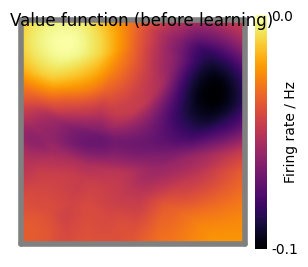

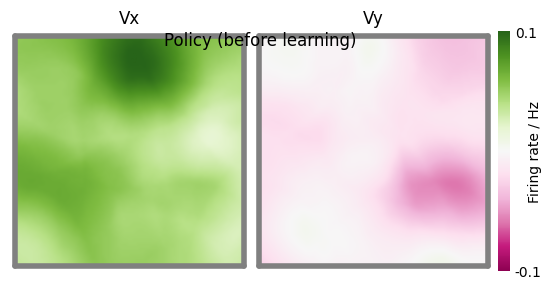

In [25]:
# MLP for the Actor and Critic

# Make the environment, egent and place cells 
env, ag = generate_navigation_task_env()
placecells = PlaceCells(ag, params={'n':50,}) 

#Make the actor and the critic (first make their core NNs then pass these to the full Actor and Critic classes)
actorNN  = VxVyGaussianMLP(n_in=placecells.n)
criticNN = MultiLayerPerceptron(n_in=placecells.n)
#
actor  = Actor(ag, params = {'input_layers':[placecells], 'NeuralNetworkModule':actorNN}); actor.colormap="PiYG"
critic = Critic(ag, params = {'input_layers':[placecells], 'NeuralNetworkModule':criticNN})

#This visualises the value function and "policy" over the entire environment
fig, ax = critic.plot_rate_map(); fig.suptitle("Value function (before learning)")
fig, ax = actor.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")

In [8]:
train_agent_episodes(env, ag, actor, critic, placecells, n_episodes=N_EPISODES)

<success fraction>: 1.00, <episode time>: 4.8:  28%|██▊       | 1411/5000 [03:09<08:03,  7.43it/s] 


(<Figure size 250x250 with 1 Axes>, <Axes: >)

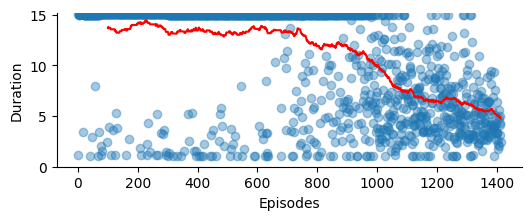

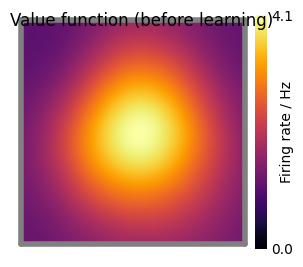

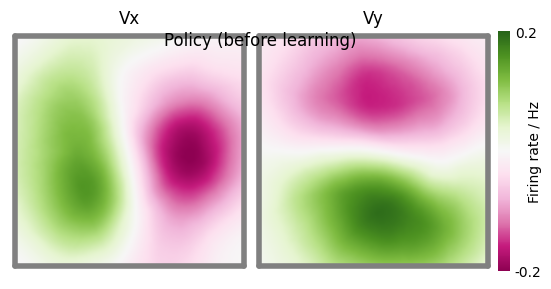

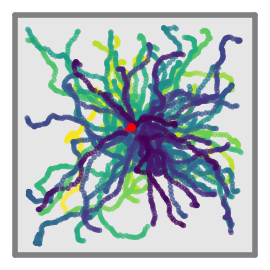

In [9]:
#This plots the reward history over training
fig, ax = plot_reward_history(env)
#This visualises the value function and "policy" over the entire environment
fig, ax = critic.plot_rate_map(); fig.suptitle("Value function (before learning)")
fig, ax = actor.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")
#Shows the trajectory of the agent over the last 100 episodes
fig, ax = ag.plot_trajectory(color="changing",t_start=env.episodes['start'][-100],t_end=env.episodes['start'][-1],); display_reward_patch(fig,ax)

 fta_eta: 0.2, n_tilings: 1, n_tiles: 10


Text(0.5, 1.0, 'Vy')

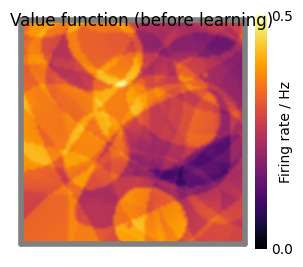

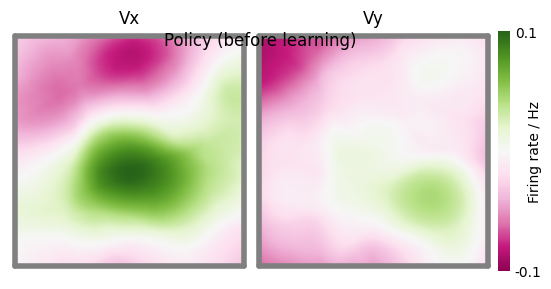

In [ ]:
env_fta, ag_fta = generate_navigation_task_env()
placecells_fta = PlaceCells(ag_fta, params={'n':50,}) 
# env.render(render_mode='matplotlib')
actorNN_fta  = VxVyGaussianMLP(n_in=placecells_fta.n)
criticNN_fta = FTANetwork(n_in=placecells_fta.n,post_fta=[1])
#
actor_fta  = Actor(ag_fta, params = {'input_layers':[placecells_fta], 'NeuralNetworkModule':actorNN_fta}); actor_fta.colormap="PiYG"
critic_fta = Critic(ag_fta, params = {'input_layers':[placecells_fta], 'NeuralNetworkModule':criticNN_fta})
fig, ax = critic_fta.plot_rate_map(); fig.suptitle("Value function (before learning)")
fig, ax = actor_fta.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")


In [29]:
train_agent_episodes(env_fta, ag_fta, actor_fta, critic_fta, placecells_fta, n_episodes=N_EPISODES)

<success fraction>: 0.21, <episode time>: 13.0: 100%|██████████| 5000/5000 [26:07<00:00,  3.19it/s]    


(<Figure size 250x250 with 1 Axes>, <Axes: >)

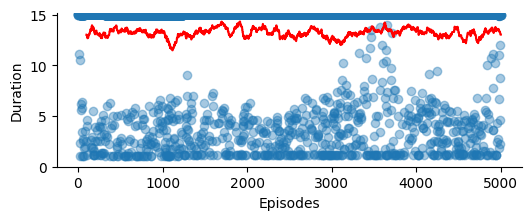

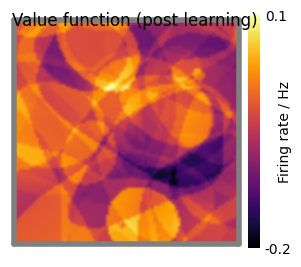

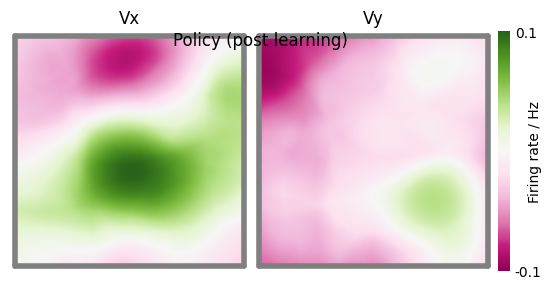

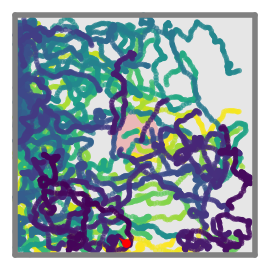

In [32]:
#This plots the reqard history over training
fig, ax = plot_reward_history(env_fta)
#This visualises the value function and "policy" over the entire environment
fig, ax = critic_fta.plot_rate_map(); fig.suptitle("Value function (post learning)")
fig, ax = actor_fta.plot_rate_map(zero_center=True); fig.suptitle("Policy (post learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")
#Shows the trajectory of the agent over the last 100 episodes
fig, ax = ag_fta.plot_trajectory(color="changing",t_start=env_fta.episodes['start'][-100],t_end=env_fta.episodes['start'][-1],); display_reward_patch(fig,ax)
